In [ ]:
!pip install transformers datasets scikit-learn pandas tqdm
!pip install torch

In [ ]:
pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/26

In [ ]:
pip install -U transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 13.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompati

In [ ]:
import torch, transformers
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)


Torch: 2.8.0+cu126
Transformers: 4.57.1


In [ ]:
pip install python-whois certifi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
import re
import urllib.parse
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score
import torch.nn as nn
import socket
import ssl
import whois
import datetime
import requests

TRUSTED_ISSUERS = ["Google Trust Services", "Let's Encrypt", "DigiCert", "GlobalSign"]
DNS_BLACKLISTS = [
    "multi.uribl.com"
]


In [ ]:
def preprocess_url(url: str, max_length: int = 256) -> str:
    if not isinstance(url, str):
        return "[EMPTY]"
    try:
        url = urllib.parse.unquote(url)
    except Exception:
        pass
    url = url.strip().strip('\'"')
    url = re.sub(r"/{2,}", "/", url)
    url = re.sub(r"\.{2,}", ".", url)
    url = re.sub(r"[^A-Za-z0-9:/?=.&_%@\-]", "", url)
    url = url.rstrip("./")
    if url != "" and not re.match(r"^[a-zA-Z]+://", url):
        url = "http://" + url
    if len(url) > max_length:
        url = url[:max_length]
    return url or "[EMPTY]"


In [ ]:

CSV_PATH = "/content/pwd.csv"

df = pd.read_csv(CSV_PATH)
assert 'URLs' in df.columns and 'label' in df.columns, "CSV must have 'url' and 'label' columns."

# drop exact duplicate rows
df = df.drop_duplicates(subset=['URLs', 'label']).reset_index(drop=True)

# apply preprocessing
df['clean_url'] = df['URLs'].apply(preprocess_url)

df = df[df['clean_url'] != "[EMPTY]"].reset_index(drop=True)
counts = df['label'].value_counts()
print("Class counts:\n", counts)


Class counts:
 label
0    29910
1    24853
Name: count, dtype: int64


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df['label'], random_state=42)
# final splits: 70% train, 10% val, 20% test

print("Sizes -> train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
print("Train class dist:\n", train_df['label'].value_counts(normalize=True))

Sizes -> train: 38333 val: 5477 test: 10953
Train class dist:
 label
0    0.546187
1    0.453813
Name: proportion, dtype: float64


In [ ]:
# rename for HF Dataset
hf_train = Dataset.from_pandas(train_df[['clean_url', 'label']].rename(columns={'clean_url':'text'}))
hf_val   = Dataset.from_pandas(val_df[['clean_url', 'label']].rename(columns={'clean_url':'text'}))
hf_test  = Dataset.from_pandas(test_df[['clean_url', 'label']].rename(columns={'clean_url':'text'}))

MODEL_NAME = "distilbert-base-cased"    # cased model to preserve case signals
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, do_lower_case=False)

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding=False, truncation=True, max_length=128)

hf_train = hf_train.map(tokenize_fn, batched=True)
hf_val   = hf_val.map(tokenize_fn, batched=True)
hf_test  = hf_test.map(tokenize_fn, batched=True)

# Remove the raw text column so Trainer uses tokenized tensors
hf_train = hf_train.remove_columns(["text", "__index_level_0__"])
hf_val   = hf_val.remove_columns(["text", "__index_level_0__"])
hf_test  = hf_test.remove_columns(["text", "__index_level_0__"])

hf_train.set_format(type="torch")
hf_val.set_format(type="torch")
hf_test.set_format(type="torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Map:   0%|          | 0/38333 [00:00<?, ? examples/s]

Map:   0%|          | 0/5477 [00:00<?, ? examples/s]

Map:   0%|          | 0/10953 [00:00<?, ? examples/s]

In [ ]:
# compute class weights inverse to frequency
labels = train_df['label'].values
classes, counts = np.unique(labels, return_counts=True)
freq = counts / counts.sum()
# weight for CrossEntropyLoss: smaller class gets larger weight
inv_freq = 1.0 / (counts + 1e-12)
weights = inv_freq / inv_freq.sum()  # normalize
# create tensor aligned with label indices [weight_for_label0, weight_for_label1]
class_weights = torch.tensor([weights[ np.where(classes==0)[0][0] ], weights[ np.where(classes==1)[0][0] ]], dtype=torch.float)
print("Class weights (for CrossEntropyLoss):", class_weights)


Class weights (for CrossEntropyLoss): tensor([0.4538, 0.5462])


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.model.device) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # forward
        outputs = model(**inputs)
        logits = outputs.get("logits")
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        else:
            # default loss
            loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch
import transformers
print("Transformers version:", transformers.__version__)

Transformers version: 4.57.1


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

print("✅ TrainingArguments works fine")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    auc = roc_auc_score(labels, pred.predictions[:,1])
    return {"precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ TrainingArguments works fine


/tmp/ipython-input-1080315923.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
print(model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1'}


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shreev-btech23 (shreev-btech23-rv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Roc Auc
1,0.101000,0.086241,0.982026,0.967015,0.974463,0.997365
2,0.050000,0.090402,0.978313,0.979887,0.979100,0.997925
3,0.017400,0.089153,0.983877,0.981899,0.982887,0.998281


TrainOutput(global_step=7188, training_loss=0.06535201425610745, metrics={'train_runtime': 1019.9846, 'train_samples_per_second': 112.746, 'train_steps_per_second': 7.047, 'total_flos': 2642158253312868.0, 'train_loss': 0.06535201425610745, 'epoch': 3.0})

Overall metrics: {'test_loss': 0.06818700581789017, 'test_precision': 0.9870576339737108, 'test_recall': 0.9818949909474954, 'test_f1': 0.9844695441710367, 'test_roc_auc': 0.999105308953078, 'test_runtime': 34.7575, 'test_samples_per_second': 315.127, 'test_steps_per_second': 19.708}
              precision    recall  f1-score   support

           0     0.9850    0.9893    0.9872      5982
           1     0.9871    0.9819    0.9845      4971

    accuracy                         0.9859     10953
   macro avg     0.9860    0.9856    0.9858     10953
weighted avg     0.9859    0.9859    0.9859     10953



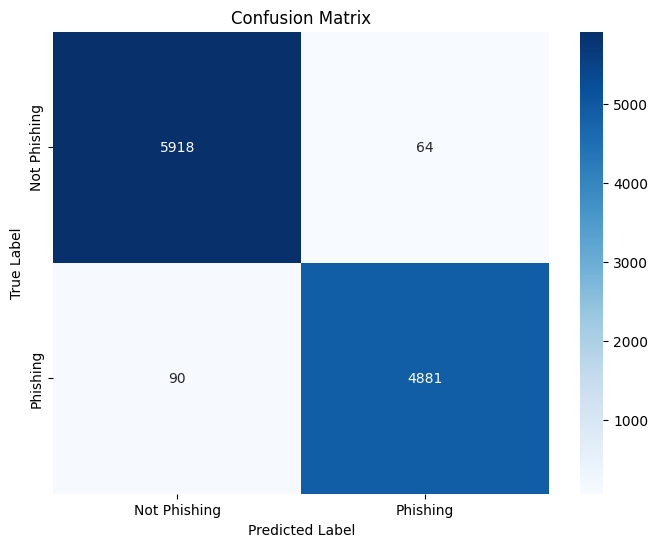

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
metrics = trainer.predict(hf_test)
print("Overall metrics:", metrics.metrics)

preds = np.argmax(metrics.predictions, axis=1)
labels = metrics.label_ids
print(classification_report(labels, preds, digits=4))

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Phishing', 'Phishing'], yticklabels=['Not Phishing', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve

# get probs for positive class
probs = torch.nn.functional.softmax(torch.tensor(metrics.predictions), dim=-1).numpy()[:,1]
precision, recall, thresh = precision_recall_curve(labels, probs)

# find threshold with recall >= desired (e.g., 0.9) and max precision
desired_recall = 0.9
candidates = [(p, r, t) for p,r,t in zip(precision, recall, np.append(thresh, 1.0)) if r >= desired_recall]
if candidates:
    best = max(candidates, key=lambda x: x[0])  # max precision
    print("Chosen threshold for recall>=%.2f -> precision=%.3f recall=%.3f thresh=%.3f" % (desired_recall, best[0], best[1], best[2]))
else:
    print("No threshold meets desired recall; adjust expectations.")


Chosen threshold for recall>=0.90 -> precision=0.998 recall=0.901 thresh=0.999


In [ ]:
trainer.save_model("./phish_model_weighted")
tokenizer.save_pretrained("./phish_model_weighted")


('./phish_model_weighted/tokenizer_config.json',
 './phish_model_weighted/special_tokens_map.json',
 './phish_model_weighted/vocab.txt',
 './phish_model_weighted/added_tokens.json',
 './phish_model_weighted/tokenizer.json')

In [ ]:
!zip -r phish_model_weighted.zip phish_model_weighted

  adding: phish_model_weighted/ (stored 0%)
  adding: phish_model_weighted/training_args.bin (deflated 53%)
  adding: phish_model_weighted/config.json (deflated 45%)
  adding: phish_model_weighted/special_tokens_map.json (deflated 42%)
  adding: phish_model_weighted/model.safetensors (deflated 8%)
  adding: phish_model_weighted/vocab.txt (deflated 49%)
  adding: phish_model_weighted/tokenizer_config.json (deflated 75%)
  adding: phish_model_weighted/tokenizer.json (deflated 70%)
